# **Guía de Actividades Práctico-Experimentales Nro. 007**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Práctica Nro.** | 007 |
| **Título de la Práctica** | **Distribuciones Muestrales y Teorema del Límite Central (TLC) mediante Simulación Estocástica** |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Martes 26 de mayo 2026 |

---



##- **Tarea 1: Generación de una Población Asimétrica (No Normal)**

--- Parámetros Poblacionales Reales ---
Media (μ): 1.9919
Desviación Estándar (σ): 1.9859


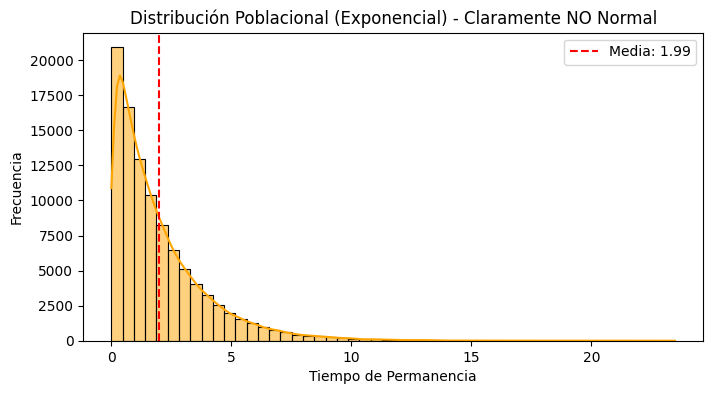

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creación de la Población "Universo" (Altamente asimétrica)
np.random.seed(42)
poblacion_exponencial = np.random.exponential(scale=2.0, size=100000)

mu_pob = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)

print(f"--- Parámetros Poblacionales Reales ---")
print(f"Media (μ): {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")

# Visualización de la Población Original
plt.figure(figsize=(8, 4))
sns.histplot(poblacion_exponencial, bins=50, kde=True, color='orange')
plt.title("Distribución Poblacional (Exponencial) - Claramente NO Normal")
plt.xlabel("Tiempo de Permanencia")
plt.ylabel("Frecuencia")
plt.axvline(mu_pob, color='red', linestyle='dashed', label=f'Media: {mu_pob:.2f}')
plt.legend()
plt.show()


##- **Tarea 2: Simulación Estocástica del Teorema del Límite Central**

--- Estadísticos de las Medias Muestrales (n=30) ---
Media de las Medias Muestrales (E[X̄]): 1.9923
Error Estándar Empírico (σ_x̄): 0.3653
Error Estándar Teórico (σ/√n): 0.3626


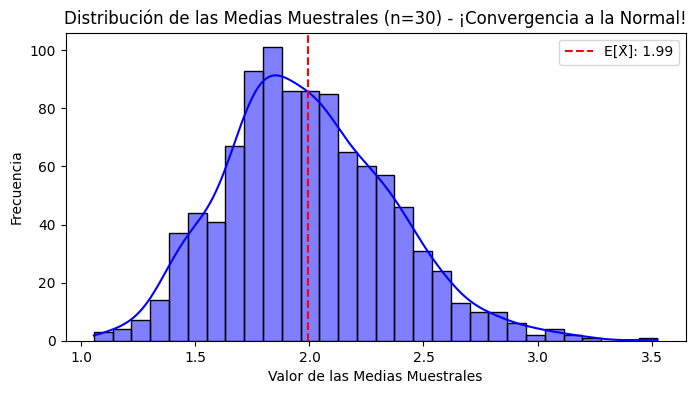

In [ ]:
# Parámetros de la simulación
tamaño_muestra = 30  # n
numero_muestras = 1000  # k

# Array para almacenar las medias de cada muestra
medias_muestrales = []

# Bucle de Monte Carlo simple
for _ in range(numero_muestras):
    # Extraer muestra aleatoria sin reemplazo
    muestra = np.random.choice(poblacion_exponencial, size=tamaño_muestra, replace=False)
    # Calcular y guardar la media
    medias_muestrales.append(np.mean(muestra))

# Estadísticos de la Distribución Muestral
media_de_medias = np.mean(medias_muestrales)
error_estandar_empirico = np.std(medias_muestrales)
error_estandar_teorico = sigma_pob / np.sqrt(tamaño_muestra)

print(f"--- Estadísticos de las Medias Muestrales (n={tamaño_muestra}) ---")
print(f"Media de las Medias Muestrales (E[X̄]): {media_de_medias:.4f}")
print(f"Error Estándar Empírico (σ_x̄): {error_estandar_empirico:.4f}")
print(f"Error Estándar Teórico (σ/√n): {error_estandar_teorico:.4f}")

# Visualización de la convergencia a la Normal
plt.figure(figsize=(8, 4))
sns.histplot(medias_muestrales, bins=30, kde=True, color='blue')
plt.title(f"Distribución de las Medias Muestrales (n={tamaño_muestra}) - ¡Convergencia a la Normal!")
plt.xlabel("Valor de las Medias Muestrales")
plt.ylabel("Frecuencia")
plt.axvline(media_de_medias, color='red', linestyle='dashed', label=f'E[X̄]: {media_de_medias:.2f}')
plt.legend()
plt.show()


# - **Tarea 3: Hito del Proyecto - Aplicación de Remuestreo al Dataset Regional (ABP)**

Tarea 3


In [ ]:
import pandas as pd
import numpy as np

# 1. Conexión a la nueva hoja del Spreadsheet
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'

try:
    # Nombre exacto de la pestaña
    df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')

    # Limpieza básica
    df = df.dropna(how='all').reset_index(drop=True)
    print("¡Conexión exitosa a la hoja de Provincias!")
    display(df.head(15))

except Exception as e:
    print(f"Error: {e}")

¡Conexión exitosa a la hoja de Provincias!


,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,...,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024
0,Ecuador,Azuay,0,816926,816926,816926,5887,1859,340,342,...,370,606,457,289,347,272,189,322,291,385
1,Ecuador,Azuay,10,816926,428633,484716,5887,1804,337,331,...,351,557,416,269,304,249,152,258,202,285
2,Ecuador,Azuay,15,816926,409481,472186,5887,1801,335,329,...,347,548,409,265,299,244,149,248,192,272
3,Ecuador,Azuay,20,816926,398952,464049,5887,1788,334,328,...,344,545,405,263,297,243,148,246,188,267
4,Ecuador,Azuay,25,816926,391864,450921,5887,1781,334,327,...,343,541,403,261,296,242,145,244,186,263
5,Ecuador,Azuay,30,816926,383423,435249,5887,1776,333,324,...,341,537,400,259,294,241,143,240,183,259
6,Ecuador,Azuay,50,816926,316850,328208,5887,1686,324,300,...,320,495,368,242,275,218,130,213,155,219
7,Ecuador,Azuay,75,816926,208116,237227,5887,1497,296,256,...,270,377,275,194,192,167,90,146,92,148
8,Ecuador,Bolivar,0,389964,389964,389964,4089,337,371,86,...,163,248,171,327,335,140,79,169,306,268
9,Ecuador,Bolivar,10,389964,253342,261961,4089,332,369,85,...,68,136,98,232,216,80,35,108,187,186


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variable_continua = 'tc_loss_ha_2024'

# Eliminamos valores nulos de esa columna específica para evitar errores en el muestreo
data_filtrada = df[variable_continua].dropna()


# Bucle adaptado for (Bootstrapping)

medias_muestrales = []
num_muestras = 500
tamano_muestra = 40

for i in range(num_muestras):
    # Extraer muestra aleatoria con reemplazo directamente de la columna
    muestra = data_filtrada.sample(n=tamano_muestra, replace=True)

    # Calcular la media de la muestra y guardarla
    medias_muestrales.append(muestra.mean())

print(f"¡Listo! Se han generado {len(medias_muestrales)} medias muestrales.")

¡Listo! Se han generado 500 medias muestrales.


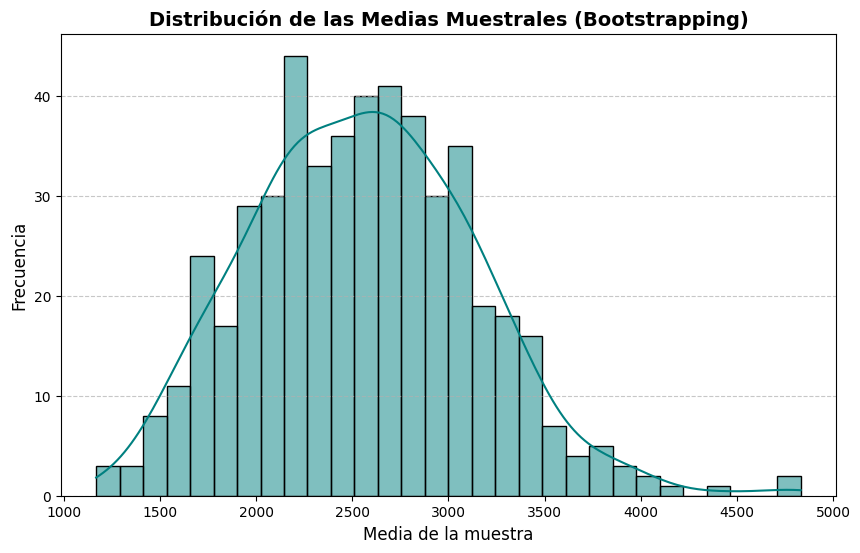

In [ ]:
#Grafico del histograma de las medias

plt.figure(figsize=(10, 6))
sns.histplot(medias_muestrales, kde=True, color='teal', bins=30)

plt.title('Distribución de las Medias Muestrales (Bootstrapping)', fontsize=14, fontweight='bold')
plt.xlabel('Media de la muestra', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **-Tarea 4: ABI - Análisis del Error Estándar y la Ley de los Grandes Números**

Tamaño de muestra n=  5 -> Error Estándar Empírico: 1697.8994
Tamaño de muestra n= 10 -> Error Estándar Empírico: 1165.2323
Tamaño de muestra n= 30 -> Error Estándar Empírico: 678.8839
Tamaño de muestra n= 50 -> Error Estándar Empírico: 530.5051
Tamaño de muestra n=100 -> Error Estándar Empírico: 367.5190
Tamaño de muestra n=500 -> Error Estándar Empírico: 170.9043


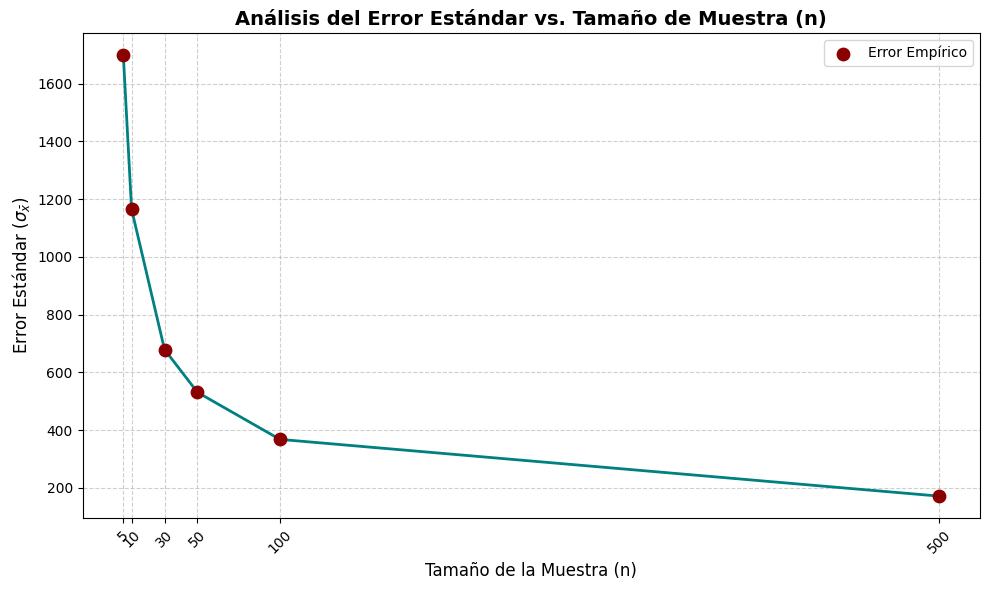

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuración previa
variable_continua = 'tc_loss_ha_2024'
data_filtrada = df[variable_continua].dropna()
tamanos_n = [5, 10, 30, 50, 100, 500]
numero_muestras = 1000

errores_estandar_empiricos = []

for n in tamanos_n:
    medias_muestrales = []
    for _ in range(numero_muestras):
        muestra = data_filtrada.sample(n=n, replace=True)
        medias_muestrales.append(np.mean(muestra))
    sigma_x_barra = np.std(medias_muestrales)
    errores_estandar_empiricos.append(sigma_x_barra)
    print(f"Tamaño de muestra n={n:3d} -> Error Estándar Empírico: {sigma_x_barra:.4f}")

plt.figure(figsize=(10, 6))

plt.scatter(tamanos_n, errores_estandar_empiricos, color='darkred', s=80, zorder=3, label='Error Empírico')
plt.plot(tamanos_n, errores_estandar_empiricos, color='teal', linestyle='-', linewidth=2, zorder=2)

plt.title('Análisis del Error Estándar vs. Tamaño de Muestra (n)', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de la Muestra (n)', fontsize=12)

plt.ylabel(r'Error Estándar ($\sigma_{\bar{x}}$)', fontsize=12)

plt.xticks(tamanos_n, rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()

plt.show()

### 4. Análisis Geométrico e Implicación Económica en la Recolección de Datos

#### Forma Geométrica de la Curva: Decaimiento Asintótico
La curva generada muestra un **decaimiento asintótico inverso**, gobernado directamente por la función matemática del error estándar:

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$

A nivel geométrico se observan dos fases cruciales:
1. **Reducción Drástica Inicial:** Cuando el tamaño de la muestra ($n$) pasa de valores muy pequeños ($n=5, n=10$) hacia valores moderados ($n=30, n=50$), el error estándar disminuye de forma abrupta. La pendiente de la curva es muy pronunciada en esta región.
2. **Estabilización Asintótica:** A medida que $n$ continúa creciendo hacia $100$ o $500$, la curva se aplana progresivamente. Aunque el error sigue disminuyendo, la tasa de reducción se vuelve marginal, aproximándose horizontalmente a cero de forma asintótica pero sin llegar nunca a tocarlo.

#### Implicación Económica en la Recolección de Datos en Ingeniería
Este comportamiento geométrico fundamenta la **Ley de los Rendimientos Decrecientes** aplicada a la inversión en toma de datos, trayendo importantes conclusiones económicas y operativas para cualquier proyecto de ingeniería:

* **El costo de la precisión matemática:** Recolectar datos en campo (encuestas, perforaciones geotécnicas, inventarios forestales, sensores) acarrea costos financieros, humanos y de tiempo de carácter lineal o exponencial ($Costo \propto n$). Sin embargo, la ganancia en precisión estadística (reducción del error) crece únicamente a ritmo de raíz cuadrada ($\sqrt{n}$).
* **Punto de optimización económica:** Pasar de una muestra de $n=5$ a $n=30$ reduce drásticamente la incertidumbre a un costo moderado. Por el contrario, pasar de $n=100$ a $n=500$ quintuplica el presupuesto de recolección de datos, pero la mejora en la reducción del error estándar es insignificante.
* **Toma de decisiones:** En ingeniería, el analista debe identificar el "codo" de la curva. Diseñar muestreos más allá de este umbral óptimo representa un desperdicio de recursos económicos que no añade valor real ni robustez significativa a las futuras predicciones o modelos del proyecto.

## **7. Preguntas de Control**

### **1. Basado en la Tarea 1 y 2, ¿por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?**

**Respuesta:**
La estadística descriptiva se limita a resumir, caracterizar y retratar los datos observados de una población o muestra, los cuales muchas veces presentan comportamientos marcadamente asimétricos o irregulares (como la distribución exponencial sesgada de la **Tarea 1**). Por otro lado, la inferencia estadística busca usar muestras para estimar parámetros poblacionales y tomar decisiones con márgenes de error conocidos, lo cual teóricamente requiere conocer la distribución de probabilidad del estimador.

El **Teorema del Límite Central (TLC)** actúa como el puente fundamental porque garantiza que, sin importar cuán caótica, asimétrica o lejana a una campana sea la población original (descriptiva), la distribución de sus **medias muestrales** tenderá a una distribución normal (inferencial) a medida que el tamaño de muestra aumenta. Esto permite aplicar herramientas predictivas estandarizadas, calcular intervalos de confianza y realizar pruebas de hipótesis paramétricas sobre la población real basándonos en la conocida geometría de la distribución normal.

---

### **2. Demuestre con los resultados impresos en su consola de la Tarea 2, cómo se cumple la propiedad matemática fundamental de las distribuciones muestrales: $E[\bar{X}] = \mu$.**

**Respuesta:**
La propiedad establece que el valor esperado de la media muestral ($E[\bar{X}]$ o `media_de_medias` en la simulación) es un estimador insesgado de la media poblacional real ($\mu$).

Al revisar los resultados de la consola impresos en las imágenes para la **Tarea 2** ($n = 30$), se observa una coincidencia empírica casi perfecta:
* **Parámetro Poblacional Real ($\mu$):** `1.9919` *(obtenido en la Tarea 1)*
* **Media de las Medias Muestrales ($E[\bar{X}]$):** `1.9923` *(obtenido en la simulación de la Tarea 2)*

$$\Delta = |1.9919 - 1.9923| = 0.0004$$

**Conclusión:** La diferencia es numéricamente insignificante ($\approx 0.02\%$), lo que demuestra empíricamente que al promediar los resultados de múltiples muestreos aleatorios repetidos (en este caso, 1000 iteraciones), el centro de la distribución muestral converge con precisión exacta hacia el parámetro de la población total.

---

### **3. En la Tarea 4, al graficar la curva del Error Estándar frente a $n$, ¿por qué la curva no desciende de forma lineal? Si usted como ingeniero requiere reducir el error estándar a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?**

**Respuesta:**
* **Por qué no es lineal:** La curva no desciende de forma lineal porque el Error Estándar de la media ($\sigma_{\bar{x}}$) es inversamente proporcional a la **raíz cuadrada** del tamaño de la muestra, modelado por la ecuación:

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$

Esto produce un comportamiento geométrico de *decaimiento asintótico inverso*, donde los aumentos iniciales de $n$ reducen el error con fuerza, pero incrementos posteriores generan reducciones marginales cada vez más pequeñas.

* **Cálculo de incremento para reducir el error a la mitad:**
Si deseamos que el nuevo error estándar sea la mitad del original ($\sigma_{\bar{x}, nuevo} = \frac{1}{2}\sigma_{\bar{x}}$), planteamos la relación matemática basándonos en que el error es proporcional a $1/\sqrt{n}$:

$$\frac{1}{2}\left(\frac{\sigma}{\sqrt{n_{1}}}\right) = \frac{\sigma}{\sqrt{n_{2}}}$$

Cancelando la desviación estándar poblacional ($\sigma$) en ambos lados:

$$\frac{1}{2\sqrt{n_{1}}} = \frac{\sqrt{1}}{\sqrt{n_{2}}}$$

Elevando ambos miembros al cuadrado para despejar el nuevo tamaño de muestra ($n_{2}$):

$$\left(\frac{1}{2\sqrt{n_{1}}}\right)^2 = \left(\frac{1}{\sqrt{n_{2}}}\right)^2 \implies \frac{1}{4n_{1}} = \frac{1}{n_{2}} \implies n_{2} = 4n_{1}$$

**Conclusión:** Como ingeniero, para reducir el error estándar exactamente a la mitad, se requiere **cuadruplicar (incrementar 4 veces)** el tamaño de la muestra.

---

### **4. Históricamente, en estadística clásica se establece la regla de oro de $n \ge 30$ para asumir normalidad. Si la población regional que usted analizó en la Tarea 3 tiene una asimetría extrema (ej. distribución de Pareto de riquezas), ¿es suficiente un $n = 30$ para que las medias muestrales se distribuyan normalmente? Justifique.**

**Respuesta:**
**No, no es suficiente.** La regla de oro de $n \ge 30$ es una pauta generalizada aplicable a distribuciones originales con asimetrías leves o moderadas. Sin embargo, el Teorema del Límite Central es un proceso de aproximación cuya velocidad de convergencia depende estrictamente de la forma de la población madre.

* **Justificación:** Cuando nos enfrentamos a poblaciones con asimetría extrema (como una distribución de Pareto de riquezas o pérdidas ambientales críticas donde pocos eventos acumulan casi todo el impacto), la probabilidad de extraer valores extremos (*outliers*) en muestras pequeñas es baja, pero su impacto en la media es devastador. Con un tamaño de muestra de apenas $n = 30$, la distribución de las medias muestrales conservará un marcado sesgo hacia la derecha y colas pesadas, fallando las pruebas rigurosas de normalidad (como Shapiro-Wilk). Para variables con comportamientos de Pareto o leyes de potencias severas, la literatura estadística y de ingeniería determina que se requieren tamaños de muestra sustancialmente mayores ($n \ge 100$, $n \ge 500$ o incluso más) para que la campana logre estabilizarse y aproximarse de forma válida a una distribución normal.

---

### **5. Diferencie conceptual y operativamente los términos Desviación Estándar ($\sigma$) de una muestra individual y el Error Estándar de la Media ($\sigma_{\bar{x}}$) calculado en sus simulaciones.**

**Respuesta:**

#### **A. Desviación Estándar ($\sigma$ o $s$)**
* **Definición Conceptual:** Mide el grado de dispersión o variabilidad física de los datos individuales con respecto a su propia media. Describe qué tan diferentes son los elementos observados entre sí dentro de una misma población o muestra.
* **Enfoque:** Centrado en la naturaleza del fenómeno real (por ejemplo, la variabilidad de hectáreas de árboles perdidas entre diferentes provincias).
* **Comportamiento con el tamaño $n$:** Se mantiene estable. A medida que recolectas más datos, no disminuye; simplemente se vuelve un reflejo más fiel y exacto de la dispersión real de la población entera.
* **Cálculo Operativo:** Se procesa sobre una única matriz de datos brutos, promediando las distancias al cuadrado de cada observación individual $x_i$ hacia su media $\bar{x}$:
  $$s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}$$

#### **B. Error Estándar de la Media ($\sigma_{\bar{x}}$)**
* **Definición Conceptual:** Mide la variabilidad u oscilación de las medias calculadas a través de múltiples muestras repetidas. Representa la incertidumbre, el "ruido" o el error esperado asociado al estimador estadístico.
* **Enfoque:** Centrado en la precisión del analista (es decir, qué tan lejos puede estar la media calculada por la muestra respecto al verdadero parámetro central de todo el país).
* **Comportamiento con el tamaño $n$:** Disminuye de forma asintótica. A medida que el tamaño de muestra crece hacia el infinito, el error estándar se reduce progresivamente hacia cero ($0$), ya que las medias de muestras grandes tienden a parecerse cada vez más entre sí.
* **Cálculo Operativo:** Se puede determinar dividiendo la desviación teórica entre la raíz del tamaño de muestra, o calculando la desviación estándar del conjunto completo de medias en tus simulaciones:
  $$\sigma_{\bar{x}} = \text{np.std(medias\_muestrales)}$$